# Demo: solving path planning using search

## Instituto Superior Técnico, University of Lisbon

**Problem statement**: given a labirynth comprising a grid of cells with obstacles, whose actions are moving UP, DOWN, LEFT, or RIGHT, with some uncertainty, use a Markov Decision Process (MDP) to find the optimal policy.

Author: Rodrigo Ventura (<rodrigo.ventura@tecnico.ulisboa.pt>)

In [67]:
from mdp import *
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

### Create MDP model

- load labyrinth from map.png
- setup rewards -- bottom-right cell and optionaly the leftmost and rightmost columns

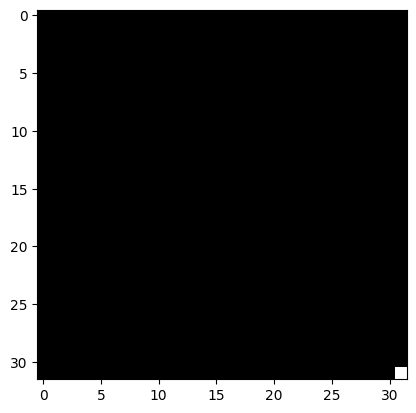

In [99]:
img = Image.open("map.png")
img.load()
img_array = np.asarray(img)
(H, W) = img_array.shape
# Note: reward of 0 is understood as an obstacle
grid = [ [(0 if c>0 else -0.01) for c in row] for row in img_array ]
grid[-1][-1] = 100

# uncomment the following lines to enable a more rich reward structure
#for i in range(H-2):
#    grid[0][i] = -50
#    grid[-1][i] = -50

plt.figure()
plt.imshow(grid, cmap='bone')
plt.show()

# note: coordinates start at bottom left at (0,0)
mdp = GridMDP(grid, terminals=[(W-1,0)], gamma=0.99)

### Obtain optimal value function

Uses the value iteration algorithm.

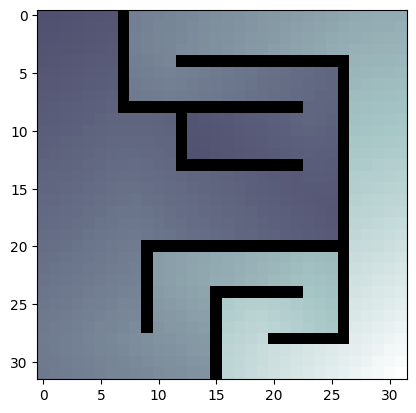

In [101]:
V = value_iteration(mdp)

V_img = np.zeros((H,W))
for (k,v) in V.items():
    V_img[k] = v

V_img = np.fliplr(V_img)  # fixes GridMDP coordinates for display purposes

plt.figure()
plt.imshow(V_img, cmap='bone')
plt.show()

### Determine the optimal policy

This can be done by either computing the best policy from the optimal value function computed above, or by running poilicy iteration instead.

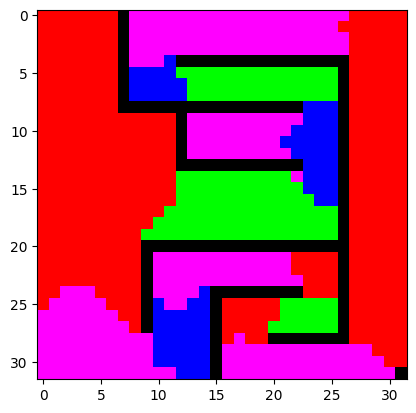

In [105]:
# Obtain optimal policy from the value function V
pi = best_policy(mdp, V)

# Uncomment the line below to use policy iteration instead
#pi = policy_iteration(mdp)

CMAP = { (1,0):[1,0,0], (0,1):[0,1,0], (-1,0):[0,0,1], (0,-1):[1,0,1] }
pi_img = np.zeros((H,W,3))
for (k,v) in pi.items():
    try:
        pi_img[k] = CMAP[v]
    except KeyError:
        pi_img[k] = [0,0,0]

pi_img = np.fliplr(pi_img)  # fixes GridMDP coordinates

plt.figure()
plt.imshow(pi_img)
plt.show()

**Policy color codes**:
- 🟥 -- GO DOWN
- 🟩 -- GO LEFT
- 🟦 -- GO UP
- 🟪 -- GO RIGHT